In [51]:
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Data Ingestion and EDA

In [52]:
data = yf.download("USDNGN=X", start="2015-01-01", end="2026-07-24")

[*********************100%***********************]  1 of 1 completed


In [53]:
data.columns = data.columns.droplevel(1)

In [54]:
data.sample(7)

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-07-28,198.899994,198.850006,195.869995,195.869995,0
2024-11-19,1667.530029,1679.660034,1658.500000,1658.739990,0
2023-10-19,765.500000,774.440002,765.500000,774.440002,0
2023-04-03,459.839996,461.000000,459.820007,459.839996,0
2018-07-24,358.970001,361.049988,359.290009,359.290009,0
2017-07-05,314.500000,346.000000,314.500000,314.500000,0
2021-09-03,411.000000,411.390015,410.549988,411.000000,0


In [55]:
def fetch_forex_data(ticker="USDNGN=X", start_date="2015-01-01", end_date="2026-07-24"):
    """
    Fetches forex data from Yahoo Finance for a given ticker and date range.

    Parameters:
    ticker (str): The ticker symbol for the forex pair (default is "USDNGN=X").
    start_date (str): The start date for the data in "YYYY-MM-DD" format (default is "2015-01-01").
    end_date (str): The end date for the data in "YYYY-MM-DD" format (default is "2026-07-24").

    Returns:
    pd.DataFrame: A DataFrame containing the forex data.
    """
    print(f"Initializing data download for {ticker}...")
    print(f"Window: From {start_date} to {end_date}")

    data = yf.download(ticker, start=start_date, end=end_date)

    # Drop the multi-level column index
    data.columns = data.columns.droplevel(1)

    if data.empty:
        raise ValueError(
            f"No data retrieved for ticker {ticker}. Verify connection or ticker symbol.")

    missing_vals = data['Close'].isnull().sum()
    print(f"Missing values in 'Close' price: {missing_vals}")

    print(f"Successfully downloaded {len(data)} rows.")
    return data


def save_data(df, directory="../data/raw", filename="raw_usd_ngn.csv"):
    """
    Saves the dataframe to a local directory.
    """
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}/")

    filepath = os.path.join(directory, filename)
    df.to_csv(filepath)
    print(f"Data saved successfully to: {filepath}")


if __name__ == "__main__":
    try:
        # Fetch data from 2015 up to 24th of July 2026
        df_fx = fetch_forex_data(
            ticker="USDNGN=X",
            start_date="2015-01-01",
            end_date="2026-07-24"
        )

        df_fx.columns = df_fx.columns.droplevel(
            1)  # Drop the multi-level column index

        # Inspect the first few rows
        print("\nSnapshot of the data:")
        print(df_fx.head())

        # Save to disk
        save_data(df_fx)

    except Exception as e:
        print(f"An error occurred: {e}")

[*********************100%***********************]  1 of 1 completed

Initializing data download for USDNGN=X...
Window: From 2015-01-01 to 2026-07-24
Missing values in 'Close' price: 0
Successfully downloaded 3008 rows.
An error occurred: Too many levels: Index has only 1 level, not 2


In [56]:
fetch_forex_data()

[*********************100%***********************]  1 of 1 completed

Initializing data download for USDNGN=X...
Window: From 2015-01-01 to 2026-07-24
Missing values in 'Close' price: 0
Successfully downloaded 3008 rows.


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,182.300003,181.380005,181.380005,181.380005,0
2015-01-02,181.380005,182.899994,181.009995,181.869995,0
2015-01-05,182.699997,183.399994,181.500000,182.350006,0
2015-01-06,183.199997,181.949997,180.979996,180.979996,0
2015-01-07,183.600006,182.279999,181.350006,182.279999,0
...,...,...,...,...,...
2026-07-17,1380.719971,1380.719971,1378.869995,1380.719971,0
2026-07-20,1379.140015,1380.359985,1378.270020,1379.140015,0
2026-07-21,1379.439941,1381.140015,1377.939941,1379.439941,0


In [57]:
save_data(df_fx)

Data saved successfully to: ../data/raw\raw_usd_ngn.csv


In [58]:
df_fx

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,182.300003,181.380005,181.380005,181.380005,0
2015-01-02,181.380005,182.899994,181.009995,181.869995,0
2015-01-05,182.699997,183.399994,181.500000,182.350006,0
2015-01-06,183.199997,181.949997,180.979996,180.979996,0
2015-01-07,183.600006,182.279999,181.350006,182.279999,0
...,...,...,...,...,...
2026-07-17,1380.719971,1380.719971,1378.869995,1380.719971,0
2026-07-20,1379.140015,1380.359985,1378.270020,1379.140015,0
2026-07-21,1379.439941,1381.140015,1377.939941,1379.439941,0


In [59]:
df_fx.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [60]:
df_fx.shape

(3008, 5)

In [61]:
df_fx.describe()

Price,Close,High,Low,Open,Volume
count,3008.000000,3008.000000,3008.000000,3008.000000,3008.0
mean,613.325236,617.392392,610.894837,614.049243,0.0
std,476.617669,478.244750,473.995850,476.143869,0.0
min,1.000000,180.419998,1.000000,175.669998,0.0
25%,355.000000,358.000000,355.000000,357.000000,0.0
50%,380.500000,385.365005,379.509995,380.700012,0.0
75%,771.044998,776.544998,764.947495,770.067505,0.0
max,1696.199951,1702.229980,1684.800049,1692.640015,0.0


In [62]:
df_fx.nunique()

Price
Close     1465
High      1635
Low       1629
Open      1690
Volume       1
dtype: int64

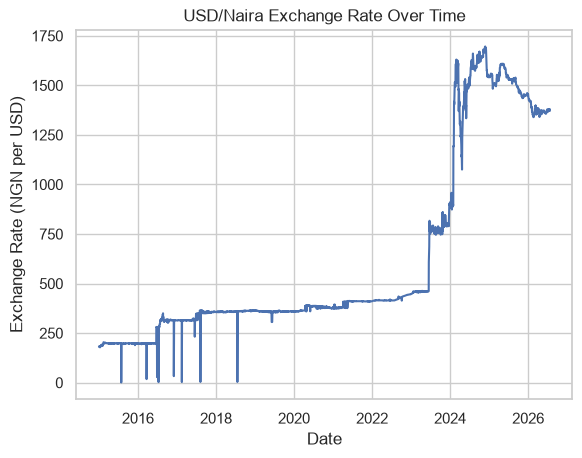

In [63]:
sns.set_theme(style="whitegrid")
sns.lineplot(data=df_fx, x=df_fx.index, y='Close')
plt.title("USD/Naira Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (NGN per USD)")
plt.savefig("../reports/figures/(USD per Naira)_Exchange_Rate_Over_Time.png",
            dpi=300, bbox_inches="tight")
plt.show()

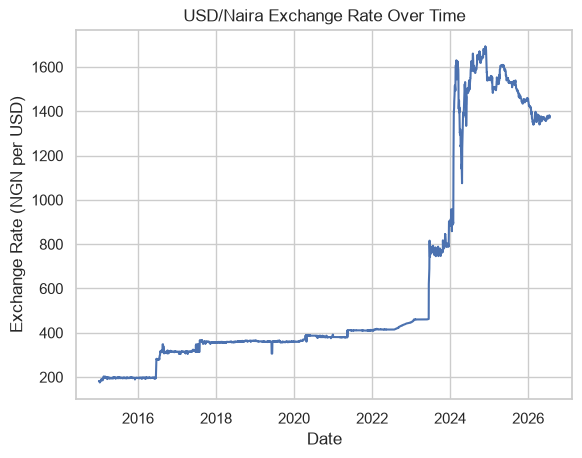

In [64]:
sns.set_theme(style="whitegrid")
sns.lineplot(data=df_fx, x=df_fx.index, y='Open')
plt.title("USD/Naira Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (NGN per USD)")
# plt.savefig("../reports/figures/(USD per Naira)_Exchange_Rate_Over_Time.png",
# dpi=300, bbox_inches="tight")
plt.show()

In [65]:
result = adfuller(df_fx['Close'].dropna())
result

NameError: name 'adfuller' is not defined

--- Raw Close Price Stationarity ---

Running Augmented Dickey-Fuller Test...
ADF Statistic: -0.3705
p-value: 9.1492e-01
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
Conclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.

--- Log Returns Stationarity ---

Running Augmented Dickey-Fuller Test...
ADF Statistic: -13.8764
p-value: 6.3262e-26
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
Conclusion: Reject the null hypothesis. The series is STATIONARY.

EDA plots saved to ../reports/figures/usd_ngn_eda_plots.png


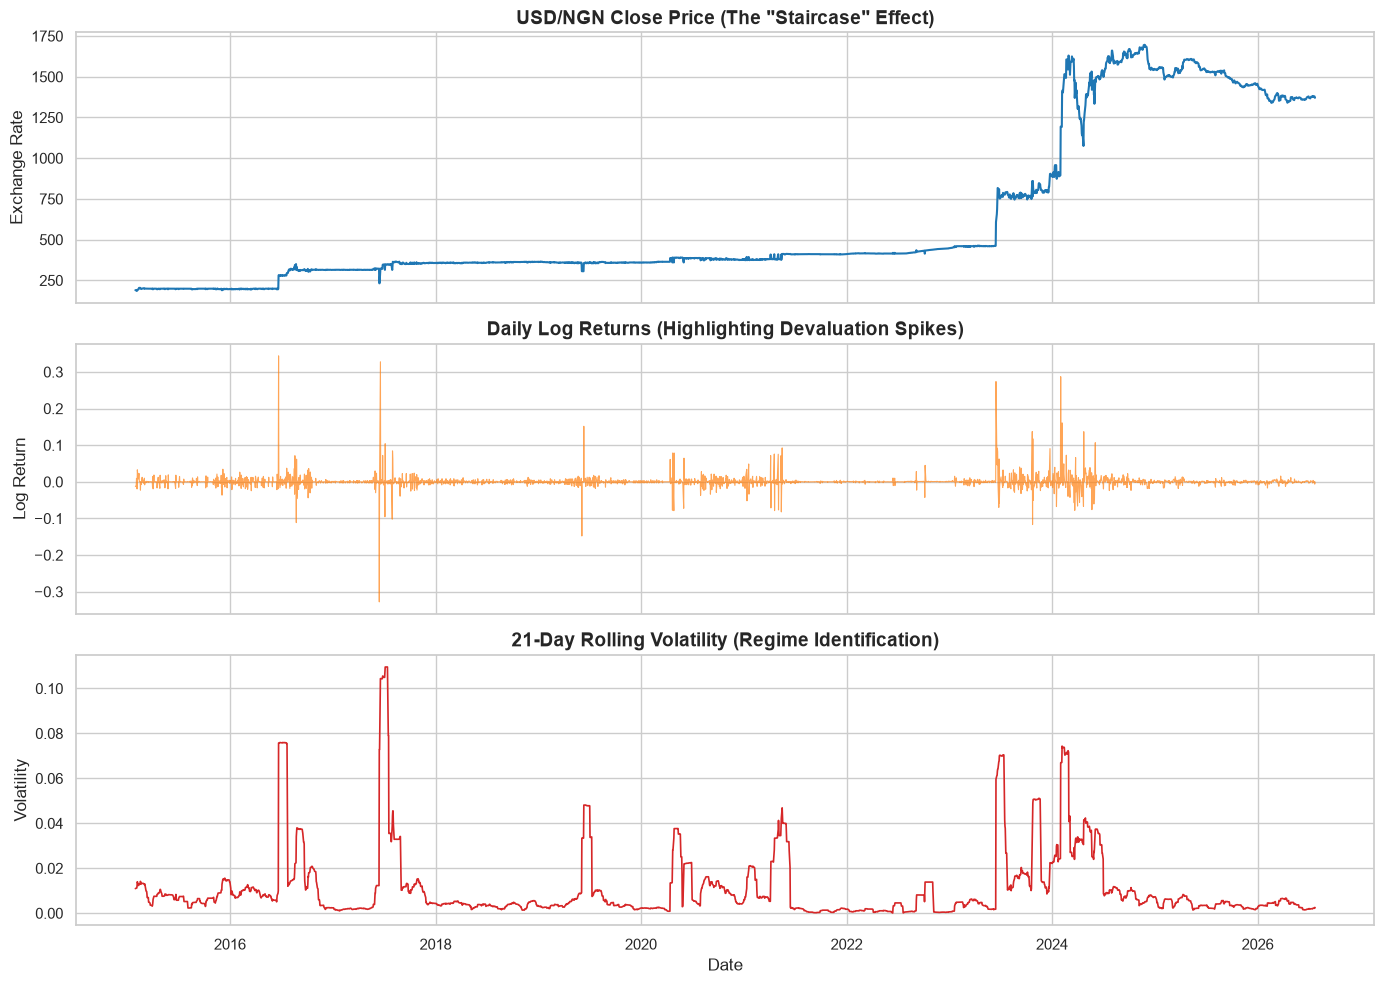

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller


def load_and_prepare_data(filepath="../data/raw/raw_usd_ngn.csv"):
    """Loads the data, handles the index, and calculates returns."""
    df = pd.read_csv(filepath, parse_dates=['Date'], index_col='Date')

    # yfinance creates multi-level columns, although I have removed that in the previous step, this is just a safeguard
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Filtering out the bad data
    # Filter out rows where 'Close' is less than or equal to 100 to adress the zero value issue
    df = df[df['Close'] > 100]

    # Standardize column name just in case
    df = df[['Close']].dropna()

    # 1. Calculate Log Returns: R_t = ln(P_t / P_{t-1})
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    # percentage changes per day
    df['pct_change'] = df['Close'].pct_change() * 100

    # 2. Calculate 21-day rolling volatility (approx. 1 business month)
    df['Rolling_Vol'] = df['Log_Returns'].rolling(window=21).std()

    return df.dropna()


def check_stationarity(series):
    """Runs the Augmented Dickey-Fuller test."""
    print("\nRunning Augmented Dickey-Fuller Test...")
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4e}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print("Conclusion: Reject the null hypothesis. The series is STATIONARY.")
    else:
        print(
            "Conclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.")


def plot_market_dynamics(df):
    """Plots price, log returns, and rolling volatility to expose regimes."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # Plot 1: Close Price
    axes[0].plot(df.index, df['Close'], color='tab:blue', linewidth=1.5)
    axes[0].set_title(
        'USD/NGN Close Price (The "Staircase" Effect)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Exchange Rate')

    # Plot 2: Log Returns
    axes[1].plot(df.index, df['Log_Returns'],
                 color='tab:orange', linewidth=0.8, alpha=0.7)
    axes[1].set_title(
        'Daily Log Returns (Highlighting Devaluation Spikes)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Log Return')

    # Plot 3: Rolling Volatility
    axes[2].plot(df.index, df['Rolling_Vol'], color='tab:red', linewidth=1.2)
    axes[2].set_title(
        '21-Day Rolling Volatility (Regime Identification)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Volatility')
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    plt.savefig('../reports/figures/usd_ngn_eda_plots.png', dpi=300)
    print("\nEDA plots saved to ../reports/figures/usd_ngn_eda_plots.png")
    plt.show()


if __name__ == "__main__":
    # Load and process
    df_processed = load_and_prepare_data()

    # Check stationarity on the raw price vs log returns
    print("--- Raw Close Price Stationarity ---")
    check_stationarity(df_processed['Close'])

    print("\n--- Log Returns Stationarity ---")
    check_stationarity(df_processed['Log_Returns'])

    # Generate the visual profile
    plot_market_dynamics(df_processed)

### Augmented Dickey-Fuller (ADF) Test for Stationarity (Raw Closing Prices)

To evaluate if the USD/NGN exchange rate time series is stationary (possessing a stable mean and variance over time) or driven by a deterministic trend, an Augmented Dickey-Fuller (ADF) test was performed on the daily closing prices.

#### Test Summary & Metrics:
* **ADF Test Statistic:** `-0.3705` — The test statistic is significantly larger (less negative) than the 5% critical value benchmark of `-2.8625`.
* **p-value:** `0.9149` (91.49%) — This is far above the standard statistical significance threshold of `0.05`.
* **Optimal Model Lags:** `10` days of lagged changes were automatically selected via AIC to account for autocorrelation.
* **Sample Size:** Evaluated across `2,998` historical trading observations.

#### Key Takeaway & Verdict:
**Verdict: The Raw Series is Non-Stationary.** Because the p-value is extremely high ($p > 0.05$) and the test statistic fails to clear any critical value thresholds, we fail to reject the null hypothesis of a unit root. This statistically confirms that the raw USD/NGN currency cross exhibits a strong, non-reverting historical trend heavily influenced by policy shifts and structural macroeconomic regimes.

---

### Log Returns Transformation & Stationarity Re-Testing

Because the raw closing prices were highly non-stationary, the data was transformed into **Log Returns** ($\ln(P_t / P_{t-1})$) to remove the trending mean. A secondary data cleaning step was implemented to filter out zero-price artifacts present in the raw data feed before re-running the test.

#### Post-Transformation Metrics:
* **ADF Statistic:** `-13.8764` (Significantly below the strict 1% critical value of `-3.4326`)
* **p-value:** $6.3262 \times 10^{-26}$ (Effectively zero, well below $\alpha = 0.05$)

#### Structural Takeaway & Modeling Insights:
**Verdict: The Log Returns series achieves Mean-Stationarity, but exhibits Volatility Clustering.** By applying the log return transformation, we successfully rejected the null hypothesis of a unit root, achieving a mean-stationary series. 

* **The Heteroskedasticity Nuance:** While the *mean* is stabilized, rolling variance analysis reveals severe **Volatility Clustering** and conditional heteroskedasticity. The variance is not constant over time; instead, periods of zero-volatility (historical peg regimes) alternate with explosive variance spikes (devaluation windows). 
* **Modeling Readiness:** Because classic linear time-series models (like vanilla ARIMA/SARIMA) assume constant variance, relying on them alone will yield poor forecasts during regime shifts. This dataset is a prime candidate for **GARCH** models to model the volatile variance, or advanced **Machine Learning / Regime-Switching Architectures** capable of dynamically adapting to shifting monetary policies.